# Phase 2.1 — Thermal Sensor Statistical Profiles

First EDA notebook for the Enbridge Wind Turbine Anomaly Detection project. Generates statistical profiles (distributions, ranges, percentiles) of all thermal sensors across Wind Farms A, B, and C.

**Goal:** Understand the baseline temperature behavior of each thermal subsystem before building Normal Behavior Models in Phase 3.

In [1]:
import sys, os
from pathlib import Path

# Add project root to sys.path so we can import from src/
PROJECT_ROOT = Path(os.getcwd()).parent if "notebooks" in os.getcwd() else Path(os.getcwd())
# Handle case where notebook is run from project root or notebooks/
for candidate in [Path("D:/Personal Projects/Enbridge Case Compettion"), PROJECT_ROOT, PROJECT_ROOT.parent]:
    if (candidate / "src").is_dir():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from src.data.load_data import load_farm_training_data
from src.features.thermal_config import (
    get_all_thermal_sensors,
    get_sensors,
    THERMAL_SUBSYSTEMS,
    SUBSYSTEM_SENSORS,
)

# Plotting defaults
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures dir:  {FIGURES_DIR}")

Project root: D:\Personal Projects\Enbridge Case Compettion
Figures dir:  D:\Personal Projects\Enbridge Case Compettion\outputs\figures


In [2]:
# Helper: compute extended summary statistics for a set of sensor columns
def thermal_summary(df: pd.DataFrame, sensors: list[str]) -> pd.DataFrame:
    """Return a DataFrame of summary stats for the given sensor columns."""
    present = [s for s in sensors if s in df.columns]
    if not present:
        return pd.DataFrame()
    desc = df[present].describe().T
    desc["skewness"] = df[present].skew()
    desc["kurtosis"] = df[present].kurtosis()
    desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skewness", "kurtosis"]]
    desc = desc.round(2)
    return desc


# Helper: map sensor columns to their subsystem for labeling
def sensor_subsystem_map(farm_key: str) -> dict[str, str]:
    """Return {sensor_col: subsystem_name} for a farm."""
    mapping = {}
    for sub, info in THERMAL_SUBSYSTEMS.items():
        for s in SUBSYSTEM_SENSORS[farm_key].get(sub, []):
            mapping[s] = info["name"]
    return mapping


# Helper: pick representative sensors for Farm C (2-3 per subsystem)
def pick_representative_sensors(farm_key: str, n_per_sub: int = 2) -> list[str]:
    """Pick first n sensors per subsystem for Farm C to keep plots manageable."""
    picked = []
    for sub in THERMAL_SUBSYSTEMS:
        sensors = SUBSYSTEM_SENSORS[farm_key].get(sub, [])
        picked.extend(sensors[:n_per_sub])
    return picked

print("Helpers defined.")

Helpers defined.


In [3]:
# Load training data for all 3 farms
print("Loading Farm A training data...")
df_a = load_farm_training_data("A")
print(f"  Farm A: {df_a.shape[0]:,} rows x {df_a.shape[1]} cols")

print("Loading Farm B training data...")
df_b = load_farm_training_data("B")
print(f"  Farm B: {df_b.shape[0]:,} rows x {df_b.shape[1]} cols")

# Farm C is ~10 GB — load only thermal sensor columns to save memory
print("Loading Farm C training data (thermal columns only)...")
thermal_c_all = get_all_thermal_sensors("farm_c")
df_c = load_farm_training_data("C")[thermal_c_all]
print(f"  Farm C: {df_c.shape[0]:,} rows x {df_c.shape[1]} cols (thermal only)")

print("\nAll farms loaded.")

Loading Farm A training data...
  Farm A: 464,694 rows x 86 cols
Loading Farm B training data...


  Farm B: 418,792 rows x 257 cols
Loading Farm C training data (thermal columns only)...


  Farm C: 1,439,077 rows x 58 cols (thermal only)

All farms loaded.


## Farm A — Thermal Sensor Summary Statistics

Farm A has **19 thermal sensors** across 6 subsystems (Gearbox, Generator/Bearings, Transformer, Hydraulic, Cooling, Nacelle/Ambient).

In [4]:
# Farm A: summary statistics for all thermal sensors
sensors_a = get_all_thermal_sensors("farm_a")
summary_a = thermal_summary(df_a, sensors_a)

# Add subsystem labels
sub_map_a = sensor_subsystem_map("farm_a")
summary_a.insert(0, "subsystem", summary_a.index.map(sub_map_a))
summary_a = summary_a.sort_values(["subsystem", "mean"], ascending=[True, False])

print(f"Farm A — {len(sensors_a)} thermal sensors\n")
summary_a.style.background_gradient(subset=["mean", "std"], cmap="YlOrRd")

Farm A — 19 thermal sensors



,subsystem,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
sensor_8_avg,Cooling,464694.000000,79.230000,28.600000,19.000000,56.000000,89.000000,99.000000,149.000000,-0.510000,-0.810000
sensor_9_avg,Cooling,464694.000000,40.320000,5.700000,26.000000,36.000000,41.000000,44.000000,66.000000,0.180000,0.410000
sensor_10_avg,Cooling,464694.000000,36.650000,5.030000,21.000000,33.000000,38.000000,39.000000,56.000000,-0.490000,0.420000
sensor_11_avg,Gearbox,464694.000000,51.760000,9.940000,21.000000,45.000000,53.000000,60.000000,72.000000,-0.510000,-0.600000
sensor_12_avg,Gearbox,464694.000000,47.710000,6.870000,21.000000,43.000000,49.000000,53.000000,65.000000,-0.660000,-0.110000
sensor_15_avg,Generator/Bearings,464694.000000,65.830000,28.710000,19.000000,44.000000,61.000000,80.000000,205.000000,0.800000,0.030000
sensor_16_avg,Generator/Bearings,464694.000000,65.130000,27.340000,19.000000,44.000000,62.000000,79.000000,205.000000,0.710000,-0.090000
sensor_17_avg,Generator/Bearings,464694.000000,64.800000,27.020000,19.000000,44.000000,61.000000,79.000000,205.000000,0.690000,-0.110000
sensor_14_avg,Generator/Bearings,464692.000000,46.260000,15.850000,17.000000,35.000000,43.000000,56.000000,205.000000,0.790000,1.620000
sensor_13_avg,Generator/Bearings,464694.000000,43.130000,13.390000,18.000000,33.000000,41.000000,52.000000,205.000000,0.850000,3.570000


C:\Users\talha\AppData\Local\Temp\ipykernel_25936\3479316745.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,


C:\Users\talha\AppData\Local\Temp\ipykernel_25936\3479316745.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,


C:\Users\talha\AppData\Local\Temp\ipykernel_25936\3479316745.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,


C:\Users\talha\AppData\Local\Temp\ipykernel_25936\3479316745.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,


C:\Users\talha\AppData\Local\Temp\ipykernel_25936\3479316745.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,


C:\Users\talha\AppData\Local\Temp\ipykernel_25936\3479316745.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,


Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\thermal_boxplots_farm_a.png


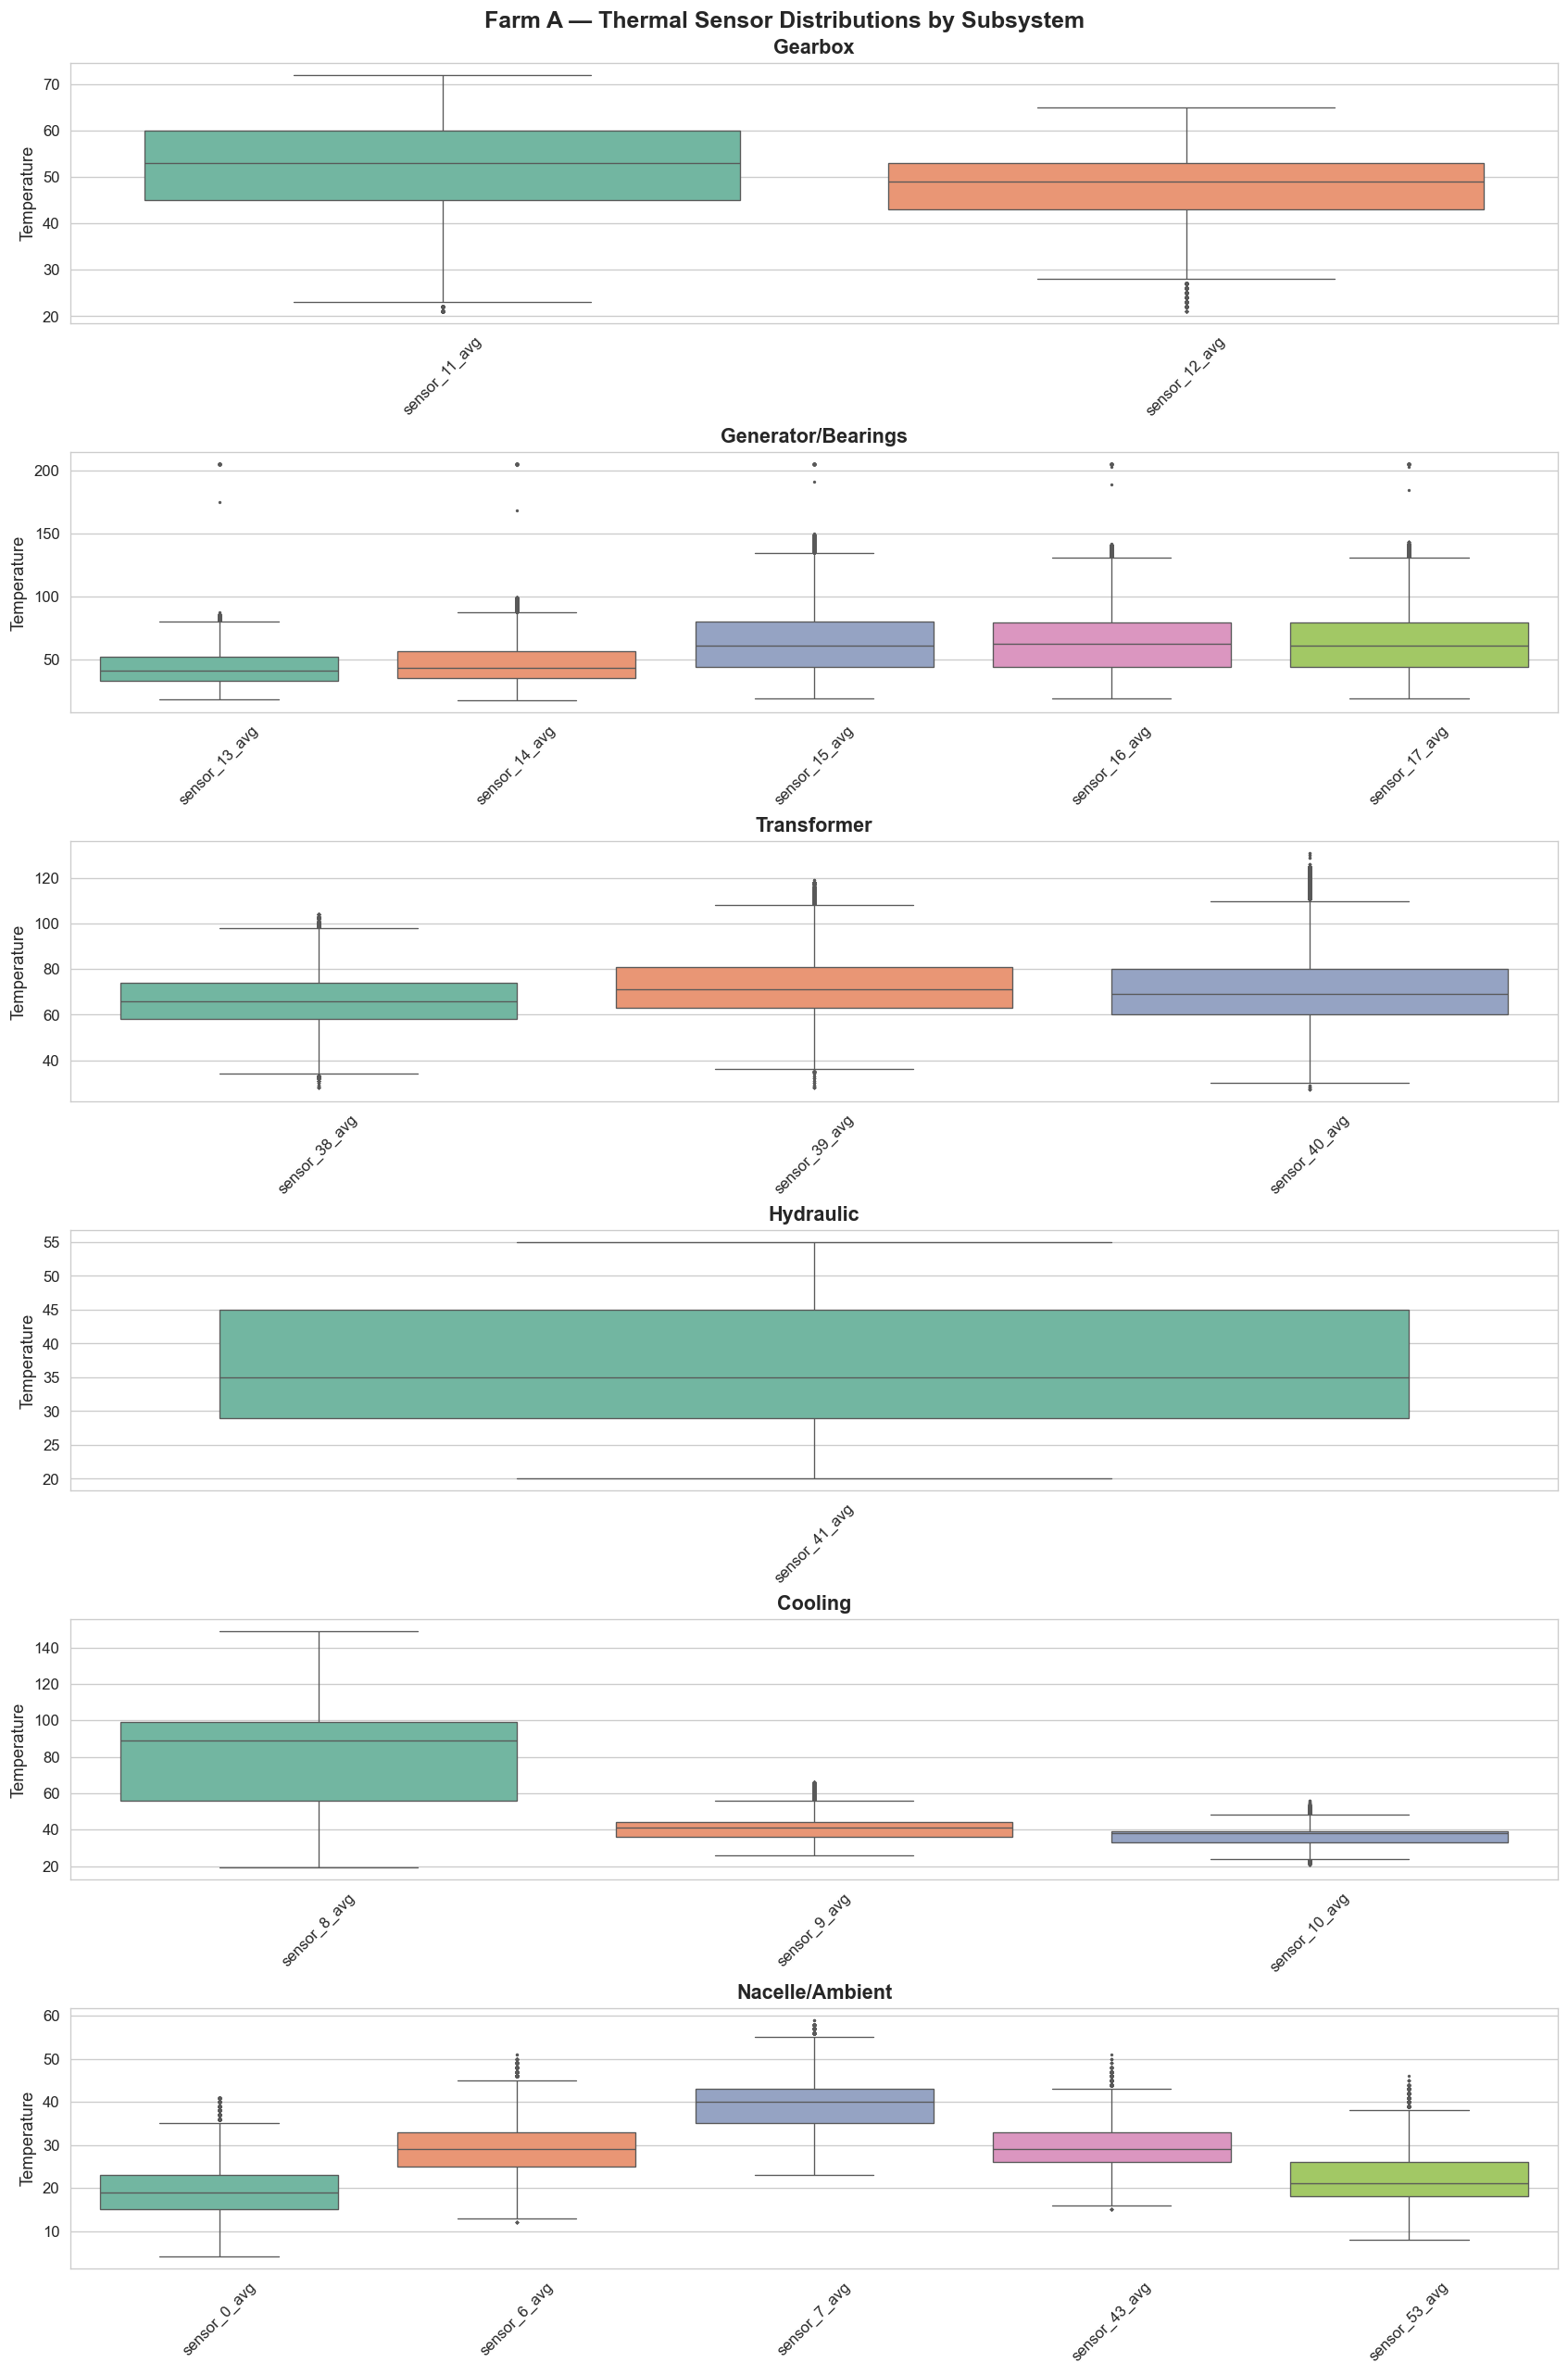

In [5]:
# Farm A: box plots organized by subsystem
sub_map_a = sensor_subsystem_map("farm_a")
subsystems_with_sensors = []
for sub_key, sub_info in THERMAL_SUBSYSTEMS.items():
    s_list = get_sensors("farm_a", sub_key)
    s_list = [s for s in s_list if s in df_a.columns]
    if s_list:
        subsystems_with_sensors.append((sub_info["name"], s_list))

n_subs = len(subsystems_with_sensors)
fig, axes = plt.subplots(n_subs, 1, figsize=(14, 3.5 * n_subs), constrained_layout=True)
if n_subs == 1:
    axes = [axes]

for ax, (sub_name, s_list) in zip(axes, subsystems_with_sensors):
    data_to_plot = df_a[s_list].dropna()
    # Melt for seaborn
    melted = data_to_plot.melt(var_name="sensor", value_name="temperature")
    sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax, 
                palette="Set2", fliersize=1, linewidth=0.8)
    ax.set_title(f"{sub_name}", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Temperature")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Farm A — Thermal Sensor Distributions by Subsystem", fontsize=15, fontweight="bold", y=1.01)
fig.savefig(FIGURES_DIR / "thermal_boxplots_farm_a.png", bbox_inches="tight", dpi=150)
print(f"Saved: {FIGURES_DIR / 'thermal_boxplots_farm_a.png'}")
plt.show()

## Farm B — Thermal Sensor Summary Statistics

Farm B has **22 thermal sensors** across 4 active subsystems (no Hydraulic or Cooling sensors mapped).

In [6]:
# Farm B: summary statistics for all thermal sensors
sensors_b = get_all_thermal_sensors("farm_b")
summary_b = thermal_summary(df_b, sensors_b)

sub_map_b = sensor_subsystem_map("farm_b")
summary_b.insert(0, "subsystem", summary_b.index.map(sub_map_b))
summary_b = summary_b.sort_values(["subsystem", "mean"], ascending=[True, False])

print(f"Farm B — {len(sensors_b)} thermal sensors ({summary_b.shape[0]} present in data)\n")
summary_b.style.background_gradient(subset=["mean", "std"], cmap="YlOrRd")

Farm B — 22 thermal sensors (22 present in data)



,subsystem,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
sensor_35_avg,Gearbox,418792.000000,62.090000,6.970000,0.000000,62.900000,64.340000,65.350000,74.920000,-2.750000,7.460000
sensor_34_avg,Gearbox,418792.000000,62.080000,6.930000,0.000000,62.650000,64.320000,65.460000,78.010000,-2.670000,7.170000
sensor_39_avg,Gearbox,418792.000000,56.070000,5.510000,0.000000,56.360000,57.610000,58.840000,72.190000,-2.840000,9.010000
sensor_36_avg,Gearbox,418792.000000,55.980000,4.710000,0.000000,56.220000,57.210000,58.060000,73.190000,-3.040000,11.540000
sensor_37_avg,Gearbox,418792.000000,55.440000,5.190000,0.000000,55.150000,56.550000,58.070000,70.500000,-2.630000,8.360000
sensor_38_avg,Gearbox,418792.000000,48.790000,5.940000,0.000000,45.670000,49.280000,53.440000,65.720000,-1.220000,2.630000
sensor_32_avg,Generator/Bearings,418792.000000,56.850000,12.370000,0.000000,50.820000,54.290000,58.880000,124.890000,2.450000,8.350000
sensor_33_avg,Generator/Bearings,418792.000000,51.470000,7.790000,0.000000,46.860000,51.350000,56.140000,84.750000,0.030000,0.360000
sensor_52_avg,Generator/Bearings,418792.000000,48.970000,9.010000,-87.540000,45.530000,50.020000,53.920000,64.780000,-7.480000,107.330000
sensor_51_avg,Generator/Bearings,418792.000000,43.940000,5.880000,0.000000,40.860000,44.730000,47.650000,62.820000,-0.830000,1.830000


C:\Users\talha\AppData\Local\Temp\ipykernel_25936\2831988288.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,


C:\Users\talha\AppData\Local\Temp\ipykernel_25936\2831988288.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,


C:\Users\talha\AppData\Local\Temp\ipykernel_25936\2831988288.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,


C:\Users\talha\AppData\Local\Temp\ipykernel_25936\2831988288.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,


Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\thermal_boxplots_farm_b.png


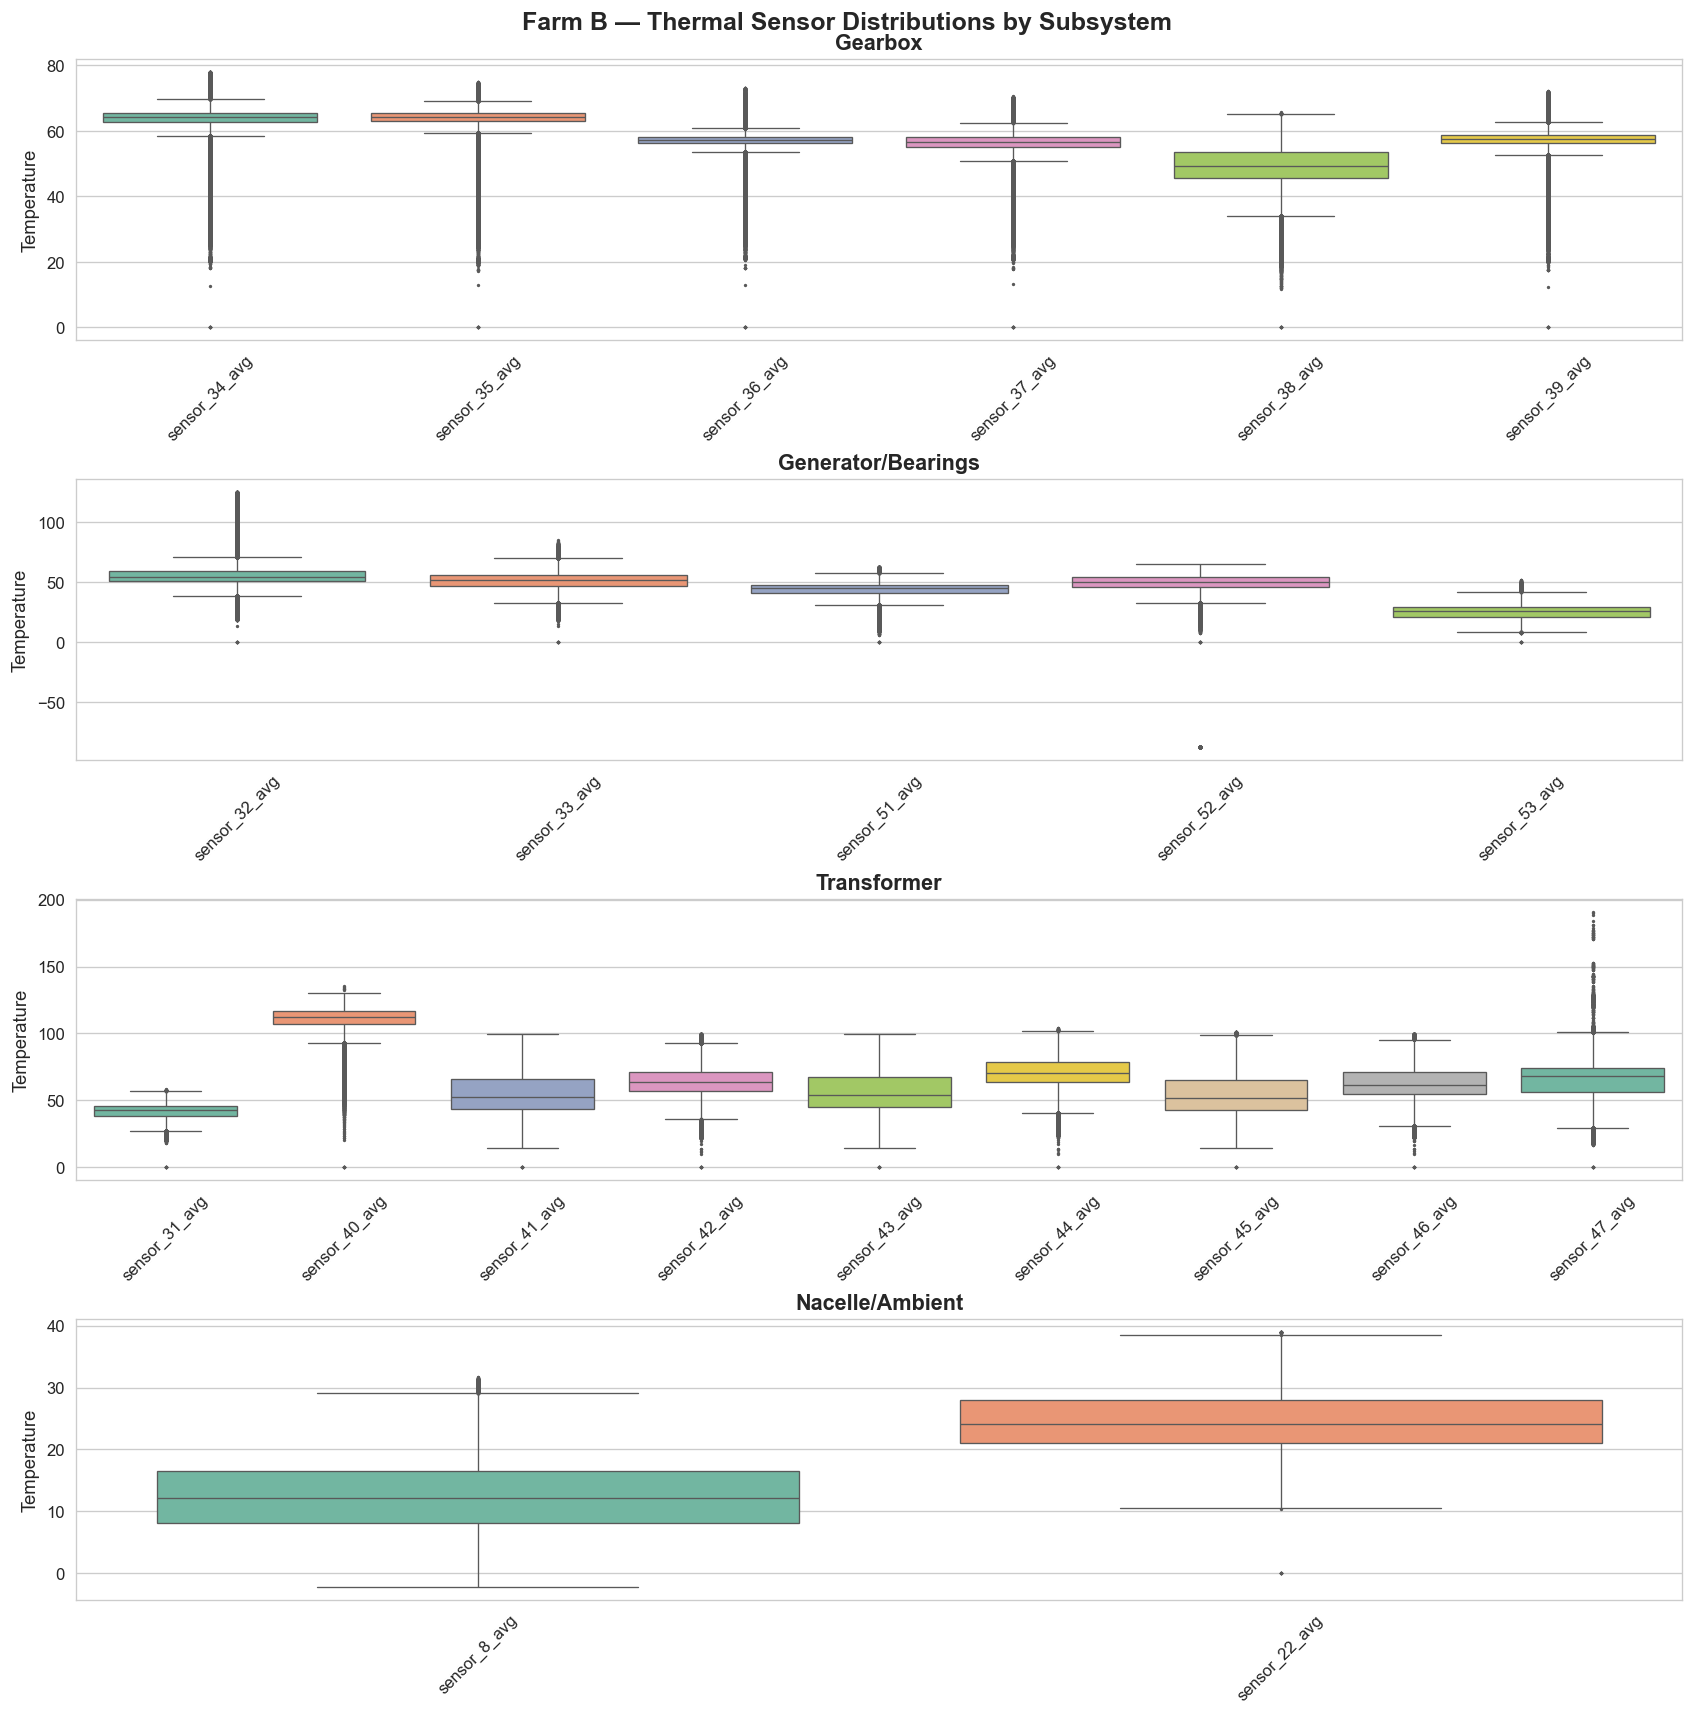

In [7]:
# Farm B: box plots organized by subsystem
subsystems_with_sensors_b = []
for sub_key, sub_info in THERMAL_SUBSYSTEMS.items():
    s_list = get_sensors("farm_b", sub_key)
    s_list = [s for s in s_list if s in df_b.columns]
    if s_list:
        subsystems_with_sensors_b.append((sub_info["name"], s_list))

n_subs_b = len(subsystems_with_sensors_b)
fig, axes = plt.subplots(n_subs_b, 1, figsize=(14, 3.5 * n_subs_b), constrained_layout=True)
if n_subs_b == 1:
    axes = [axes]

for ax, (sub_name, s_list) in zip(axes, subsystems_with_sensors_b):
    data_to_plot = df_b[s_list].dropna()
    melted = data_to_plot.melt(var_name="sensor", value_name="temperature")
    sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,
                palette="Set2", fliersize=1, linewidth=0.8)
    ax.set_title(f"{sub_name}", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Temperature")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Farm B — Thermal Sensor Distributions by Subsystem", fontsize=15, fontweight="bold", y=1.01)
fig.savefig(FIGURES_DIR / "thermal_boxplots_farm_b.png", bbox_inches="tight", dpi=150)
print(f"Saved: {FIGURES_DIR / 'thermal_boxplots_farm_b.png'}")
plt.show()

## Farm C — Thermal Sensor Summary Statistics

Farm C has **77 thermal sensors** — far more instrumentation than A or B. To keep analysis readable, we show **2-3 representative sensors per subsystem** for plots, but compute full summary stats.

In [8]:
# Farm C: summary statistics — representative sensors (2-3 per subsystem)
repr_sensors_c = pick_representative_sensors("farm_c", n_per_sub=3)
repr_sensors_c = [s for s in repr_sensors_c if s in df_c.columns]

summary_c = thermal_summary(df_c, repr_sensors_c)

sub_map_c = sensor_subsystem_map("farm_c")
summary_c.insert(0, "subsystem", summary_c.index.map(sub_map_c))
summary_c = summary_c.sort_values(["subsystem", "mean"], ascending=[True, False])

print(f"Farm C — {len(get_all_thermal_sensors('farm_c'))} total thermal sensors, showing {len(repr_sensors_c)} representatives\n")
summary_c.style.background_gradient(subset=["mean", "std"], cmap="YlOrRd")

Farm C — 58 total thermal sensors, showing 17 representatives



,subsystem,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
sensor_175_avg,Cooling,1438937.000000,32.010000,9.190000,0.000000,25.060000,31.390000,38.610000,66.500000,0.230000,-0.520000
sensor_46_avg,Cooling,1439077.000000,30.220000,2.120000,0.000000,29.290000,29.560000,30.890000,50.720000,0.030000,6.360000
sensor_176_avg,Cooling,1438937.000000,22.550000,9.470000,-1.380000,15.120000,21.520000,28.880000,69.200000,0.550000,-0.020000
sensor_152_avg,Gearbox,1438937.000000,57.570000,9.780000,-3276.700000,52.570000,58.570000,63.160000,72.760000,-167.470000,56686.130000
sensor_151_avg,Gearbox,1438937.000000,53.530000,4.720000,0.000000,50.680000,54.500000,57.090000,63.900000,-0.940000,1.200000
sensor_153_avg,Gearbox,1438937.000000,52.020000,76.710000,-3276.700000,50.750000,54.720000,57.590000,64.070000,-43.060000,1862.170000
sensor_19_avg,Generator/Bearings,1438937.000000,50.660000,6.670000,0.000000,47.070000,51.460000,54.300000,74.830000,-0.510000,1.630000
sensor_18_avg,Generator/Bearings,1438937.000000,50.590000,6.690000,0.000000,47.000000,51.340000,54.270000,73.970000,-0.480000,1.610000
sensor_20_avg,Generator/Bearings,1438937.000000,50.180000,6.610000,0.000000,46.640000,51.010000,53.870000,74.060000,-0.520000,1.620000
sensor_179_avg,Hydraulic,1438937.000000,22.190000,5.140000,0.000000,17.980000,21.300000,25.600000,52.580000,0.600000,-0.400000


C:\Users\talha\AppData\Local\Temp\ipykernel_25936\3558242393.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,
C:\Users\talha\AppData\Local\Temp\ipykernel_25936\3558242393.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,


C:\Users\talha\AppData\Local\Temp\ipykernel_25936\3558242393.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,
C:\Users\talha\AppData\Local\Temp\ipykernel_25936\3558242393.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,


C:\Users\talha\AppData\Local\Temp\ipykernel_25936\3558242393.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,
C:\Users\talha\AppData\Local\Temp\ipykernel_25936\3558242393.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,


Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\thermal_boxplots_farm_c.png


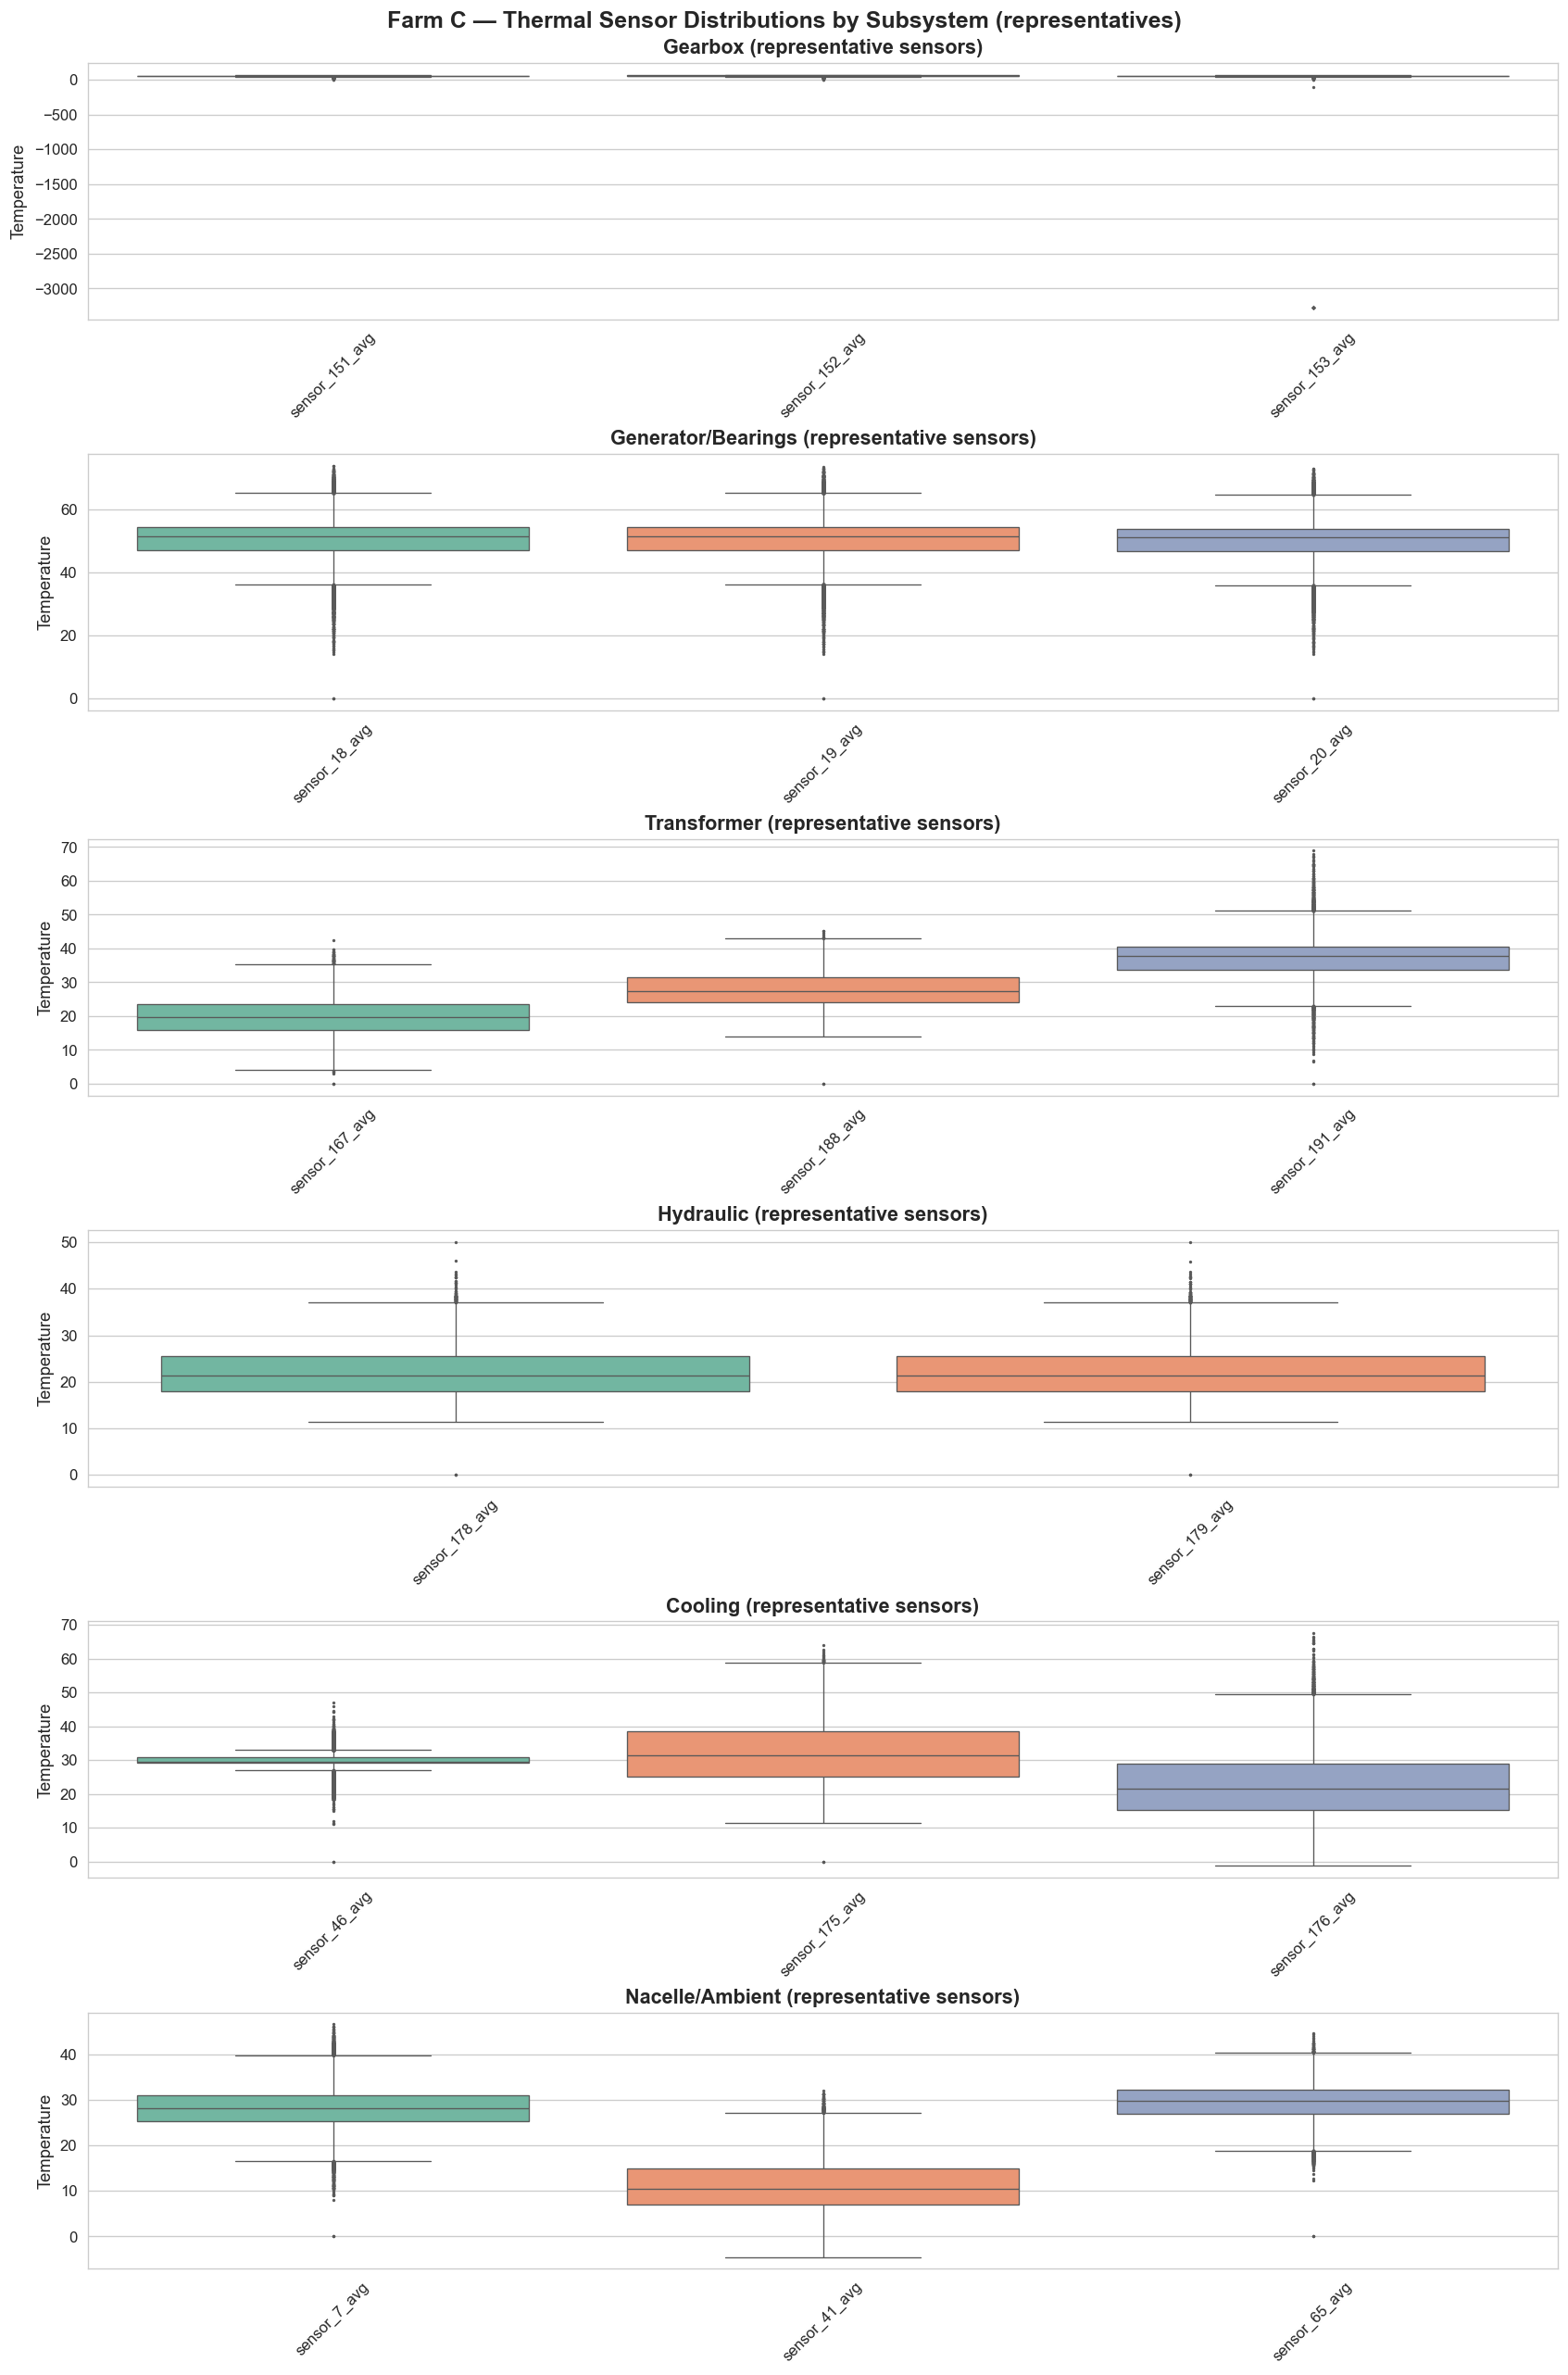

In [9]:
# Farm C: box plots for representative sensors by subsystem
subsystems_with_sensors_c = []
for sub_key, sub_info in THERMAL_SUBSYSTEMS.items():
    s_list = get_sensors("farm_c", sub_key)[:3]  # max 3 per subsystem
    s_list = [s for s in s_list if s in df_c.columns]
    if s_list:
        subsystems_with_sensors_c.append((sub_info["name"], s_list))

n_subs_c = len(subsystems_with_sensors_c)
fig, axes = plt.subplots(n_subs_c, 1, figsize=(14, 3.5 * n_subs_c), constrained_layout=True)
if n_subs_c == 1:
    axes = [axes]

for ax, (sub_name, s_list) in zip(axes, subsystems_with_sensors_c):
    # Sample for plotting speed — Farm C has 1.4M rows
    sample = df_c[s_list].dropna().sample(n=min(50_000, len(df_c)), random_state=42)
    melted = sample.melt(var_name="sensor", value_name="temperature")
    sns.boxplot(data=melted, x="sensor", y="temperature", ax=ax,
                palette="Set2", fliersize=1, linewidth=0.8)
    ax.set_title(f"{sub_name} (representative sensors)", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Temperature")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Farm C — Thermal Sensor Distributions by Subsystem (representatives)", fontsize=15, fontweight="bold", y=1.01)
fig.savefig(FIGURES_DIR / "thermal_boxplots_farm_c.png", bbox_inches="tight", dpi=150)
print(f"Saved: {FIGURES_DIR / 'thermal_boxplots_farm_c.png'}")
plt.show()

## Cross-Farm Temperature Ranges Comparison

Compare temperature ranges for equivalent subsystems across farms. Since sensor names differ between farms, we use the harmonization map to group by subsystem and compare aggregate ranges (min-max) and median values.

In [10]:
# Build cross-farm comparison: for each subsystem, compute aggregate stats per farm
# Use 1st-99th percentile for range to avoid extreme outliers (e.g. -3276 sentinel values)
import json

cross_farm_rows = []

farm_data = {"A": df_a, "B": df_b, "C": df_c}
farm_keys = {"A": "farm_a", "B": "farm_b", "C": "farm_c"}

for sub_key, sub_info in THERMAL_SUBSYSTEMS.items():
    sub_name = sub_info["name"]
    for farm_letter in ["A", "B", "C"]:
        fk = farm_keys[farm_letter]
        sensors = get_sensors(fk, sub_key)
        df = farm_data[farm_letter]
        present = [s for s in sensors if s in df.columns]
        if not present:
            continue
        # Stack all sensor values for this subsystem into one Series
        vals = df[present].values.flatten()
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0:
            continue
        cross_farm_rows.append({
            "subsystem": sub_name,
            "farm": f"Farm {farm_letter}",
            "n_sensors": len(present),
            "min_raw": np.min(vals),
            "p01": np.percentile(vals, 1),
            "p25": np.percentile(vals, 25),
            "median": np.median(vals),
            "p75": np.percentile(vals, 75),
            "p99": np.percentile(vals, 99),
            "max_raw": np.max(vals),
            "mean": np.mean(vals),
            "std": np.std(vals),
        })

cross_df = pd.DataFrame(cross_farm_rows).round(2)

# Flag extreme outliers for the observations section
print("Subsystems with extreme raw min/max (potential sentinel values):")
for _, row in cross_df.iterrows():
    if row["min_raw"] < -100 or row["max_raw"] > 300:
        print(f"  {row['farm']} {row['subsystem']}: raw range [{row['min_raw']}, {row['max_raw']}]")
print()
cross_df

Subsystems with extreme raw min/max (potential sentinel values):
  Farm C Gearbox: raw range [-3276.7, 109.19]
  Farm C Generator/Bearings: raw range [0.0, 850.0]



,subsystem,farm,n_sensors,min_raw,p01,p25,median,p75,p99,max_raw,mean,std
0,Gearbox,Farm A,2,21.00,29.00,43.00,51.00,56.00,67.00,72.00,49.73,8.78
1,Gearbox,Farm B,6,0.00,32.59,54.55,57.52,62.85,66.86,78.01,56.74,7.47
2,Gearbox,Farm C,20,-3276.70,38.56,49.44,54.80,59.20,69.80,109.19,54.52,21.72
3,Generator/Bearings,Farm A,5,17.00,22.00,37.00,53.00,68.00,132.00,205.00,57.03,25.48
4,Generator/Bearings,Farm B,5,-87.54,16.51,38.07,47.73,53.39,82.28,124.89,45.36,13.71
5,Generator/Bearings,Farm C,19,0.00,33.55,47.33,52.30,62.08,102.14,850.00,57.14,36.29
6,Transformer,Farm A,3,27.00,36.00,60.00,69.00,78.00,112.00,131.00,69.12,15.93
7,Transformer,Farm B,9,0.00,28.60,46.87,62.03,75.54,121.64,190.87,64.80,22.50
8,Transformer,Farm C,4,0.00,11.88,23.76,31.14,37.88,49.21,69.84,30.62,9.06
9,Hydraulic,Farm A,1,20.00,24.00,29.00,35.00,45.00,53.00,55.00,36.97,8.68


Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\thermal_cross_farm_ranges.png


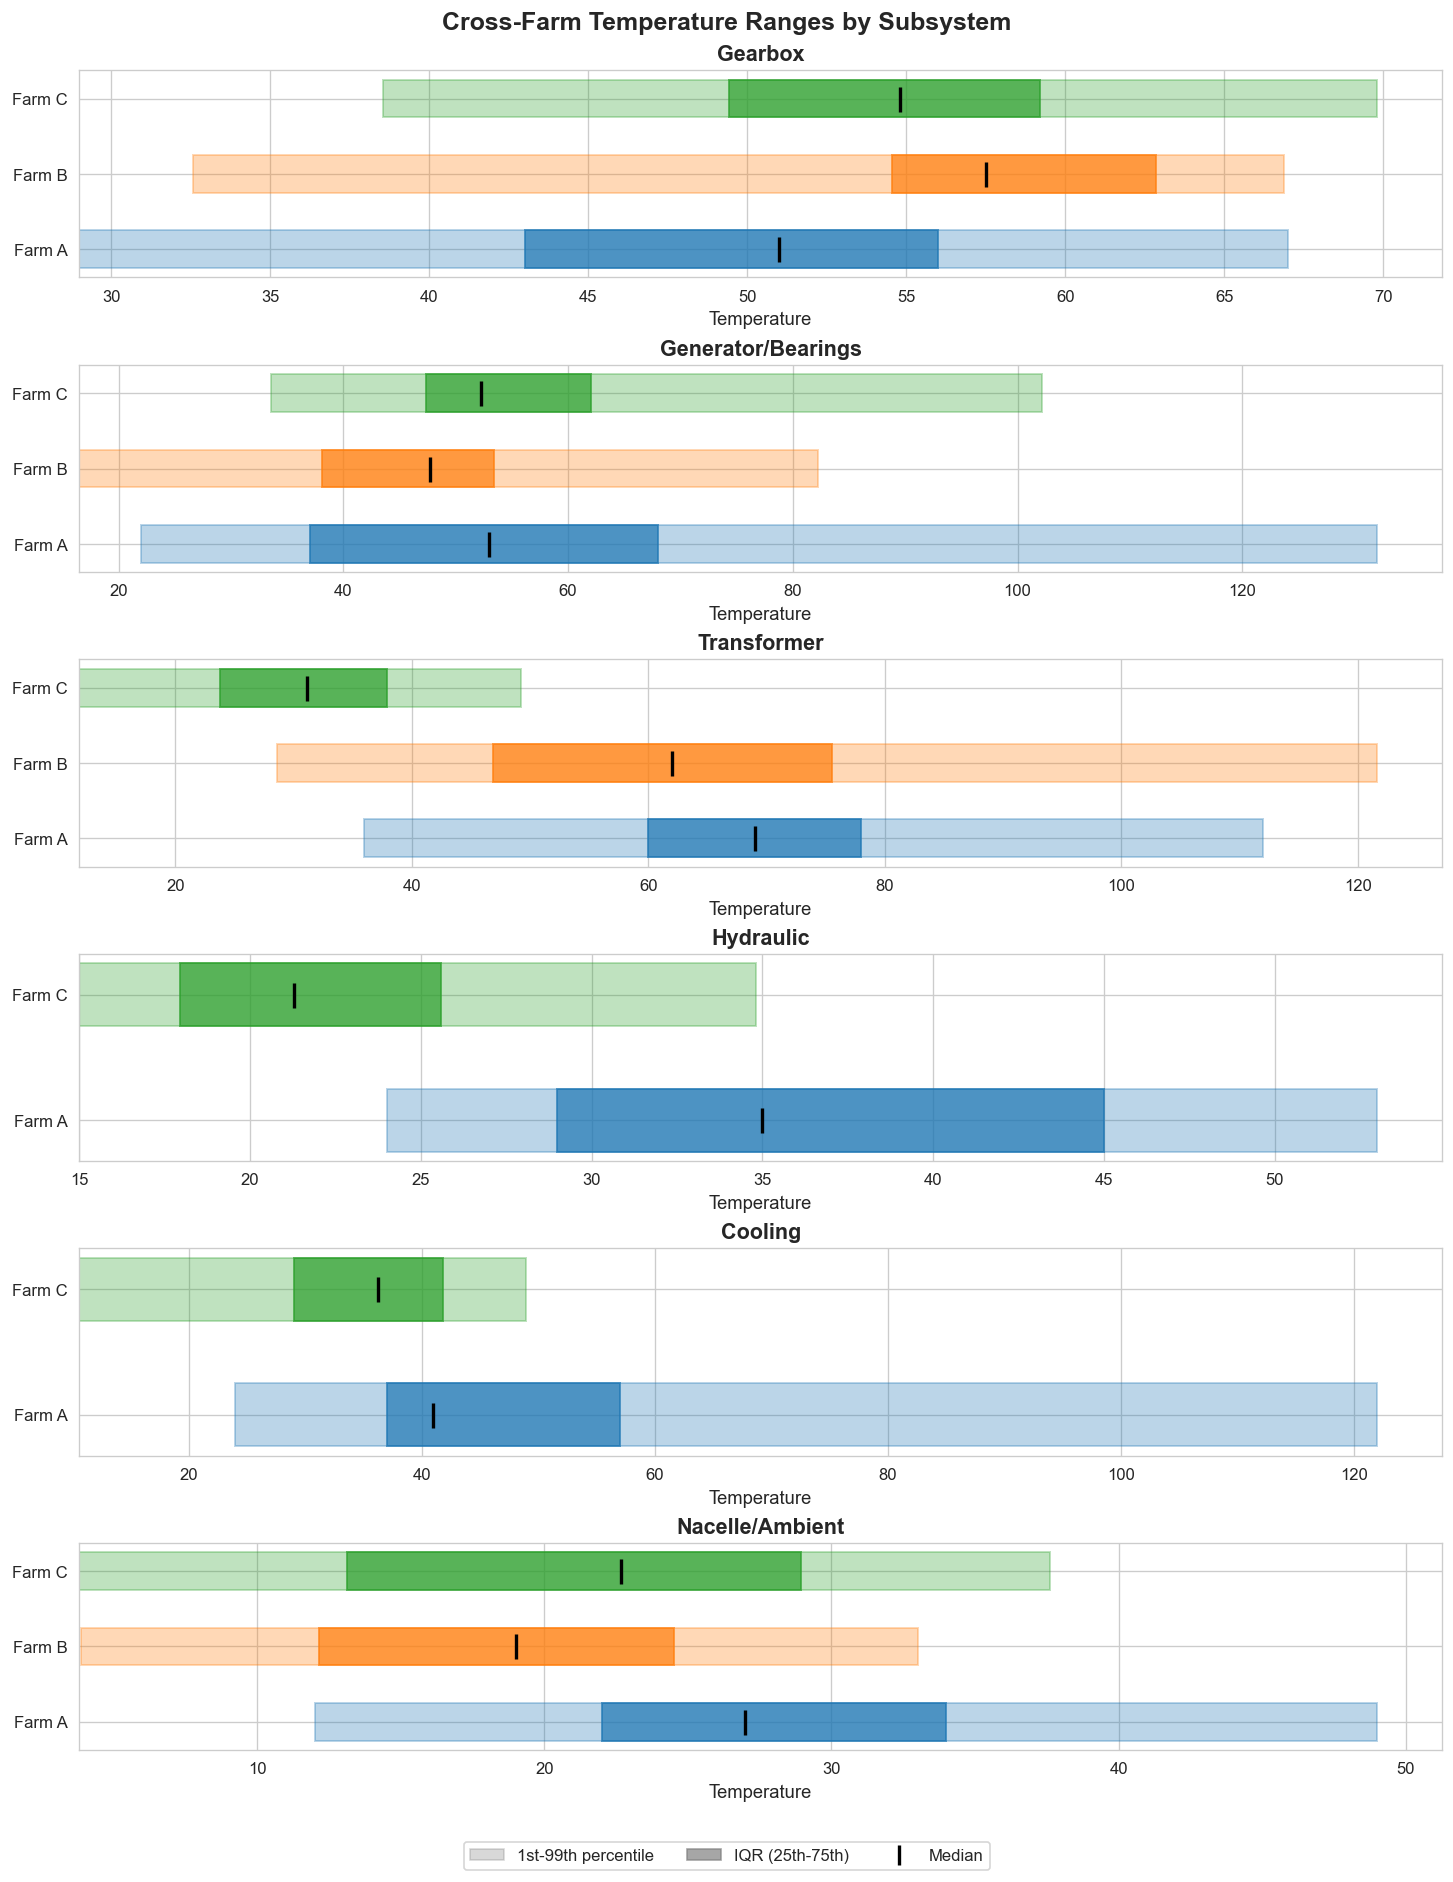

In [11]:
# Cross-farm temperature range comparison chart
# Horizontal bar chart: 1st-99th percentile range (to exclude sentinel outliers)
# with IQR (25th-75th) and median marker per farm/subsystem

subsystems_to_plot = list(cross_df["subsystem"].unique())
farm_colors = {"Farm A": "#1f77b4", "Farm B": "#ff7f0e", "Farm C": "#2ca02c"}

fig, axes = plt.subplots(len(subsystems_to_plot), 1, figsize=(12, 2.5 * len(subsystems_to_plot)),
                          constrained_layout=True)
if len(subsystems_to_plot) == 1:
    axes = [axes]

for ax, sub_name in zip(axes, subsystems_to_plot):
    sub_data = cross_df[cross_df["subsystem"] == sub_name].reset_index(drop=True)
    
    for i, (_, row) in enumerate(sub_data.iterrows()):
        color = farm_colors.get(row["farm"], "gray")
        # Outer bar: 1st-99th percentile range (avoids sentinel values)
        ax.barh(i, row["p99"] - row["p01"], left=row["p01"], height=0.5,
                color=color, alpha=0.3, edgecolor=color, linewidth=1.2)
        # Inner bar: IQR (25th-75th)
        ax.barh(i, row["p75"] - row["p25"], left=row["p25"], height=0.5,
                color=color, alpha=0.7, edgecolor=color, linewidth=1.2)
        # Median marker
        ax.plot(row["median"], i, marker="|", color="black", markersize=15, markeredgewidth=2)
    
    ax.set_yticks(range(len(sub_data)))
    ax.set_yticklabels(sub_data["farm"].values)
    ax.set_title(sub_name, fontweight="bold")
    ax.set_xlabel("Temperature")

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor="gray", alpha=0.3, edgecolor="gray", label="1st-99th percentile"),
    Patch(facecolor="gray", alpha=0.7, edgecolor="gray", label="IQR (25th-75th)"),
    Line2D([0], [0], marker="|", color="black", linestyle="None", markersize=12, markeredgewidth=2, label="Median"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.04), fontsize=10)

fig.suptitle("Cross-Farm Temperature Ranges by Subsystem", fontsize=15, fontweight="bold")
fig.savefig(FIGURES_DIR / "thermal_cross_farm_ranges.png", bbox_inches="tight", dpi=150)
print(f"Saved: {FIGURES_DIR / 'thermal_cross_farm_ranges.png'}")
plt.show()

In [12]:
# Print summary of all saved figures
print("=" * 60)
print("Figures saved to outputs/figures/:")
print("=" * 60)
for f in sorted(FIGURES_DIR.glob("thermal_*.png")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:45s} ({size_kb:.0f} KB)")

Figures saved to outputs/figures/:
  thermal_boxplots_farm_a.png                   (177 KB)
  thermal_boxplots_farm_b.png                   (129 KB)
  thermal_boxplots_farm_c.png                   (215 KB)
  thermal_cross_farm_ranges.png                 (122 KB)


## Key Observations

*(Fill in after reviewing the plots above)*

- **Gearbox temperatures:**
  - 
- **Generator/Bearings temperatures:**
  - 
- **Transformer temperatures:**
  - 
- **Hydraulic temperatures:**
  - 
- **Cooling system temperatures:**
  - 
- **Nacelle/Ambient temperatures:**
  - 
- **Cross-farm differences:**
  - 
- **Outliers / suspicious ranges:**
  - 
- **Implications for Normal Behavior Modeling (Phase 3):**
  - 